# Charging a strategy for the class it was chosen from

**Docker image**: `ml4t`

**Book Reference**: Chapter 16, §16.7 - strategy-level overfitting control.

This notebook demonstrates the Rademacher Anti-Serum (RAS) protocol for
backtest overfitting detection using `ml4t-diagnostic`.

**Learning objectives**

- Estimate empirical Rademacher complexity for a finite strategy class.
- Apply RAS bounds in native-frequency units before annualizing the result.
- Contrast the assumptions and outputs of RAS and the Deflated Sharpe Ratio (DSR).
- Interpret RAS diagnostics for Sharpe ratios, information coefficients, and parameter grids.

**Prerequisites**: Familiarity with Sharpe ratios, information coefficients,
multiple testing, and NumPy array operations.

## Two corrections, two different questions

| Aspect | DSR | RAS |
|--------|-----|-----|
| Correlation | Raw trial count needs a separate effective-trials adjustment | Uses the candidate performance matrix |
| Assumption | Asymptotic Sharpe sampling approximation | Finite-sample sub-Gaussian lower bound |
| Output | Tail probability above a selection benchmark | Lower performance bound |
| Computation | Closed form after trial statistics are known | Monte Carlo complexity estimate |

## The vocabulary, defined once

- **Rademacher Complexity (R̂)**: Measures a candidate class's capacity to fit random signs
- **Massart's Bound**: A scale-aware upper bound for a finite candidate class
- **RAS Adjustment**: θ ≥ θ̂ - 2R̂ - estimation_error
- **Data Snooping Bias**: Selection bias from picking the "best" strategy

## References

- Paleologo, G. (2024). "Elements of Quantitative Investing", Chapter 8
- Mohri, Rostamizadeh & Talwalkar (2018). "Foundations of Machine Learning"

In [1]:
"""Demonstrate Rademacher complexity adjustments for strategy selection."""

import math

import numpy as np

# Visualization
import plotly.graph_objects as go

# ml4t-diagnostic RAS functions
from ml4t.diagnostic.evaluation.stats import (
    deflated_sharpe_ratio_from_statistics,
    rademacher_complexity,
    ras_ic_adjustment,
    ras_sharpe_adjustment,
)
from plotly.subplots import make_subplots
from scipy import stats

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_SIMULATIONS = 5000
CLASS_PERIODS = 252
CLASS_CANDIDATES = 100
SWEEP_PERIODS = 504
SWEEP_CANDIDATES = 500
IC_PERIODS = 252
IC_SIGNALS = 50
IC_TRUE_SIGNALS = 5
IC_TRUE_VALUE = 0.03
IC_KAPPA = 0.1
IC_HURDLE = 0.01
GRID_HURDLE = 0.5
HOURLY_DAYS = 90
CHECK_SHARPE = 1.0
CHECK_SAMPLES = 504
CHECK_TRIALS = 100
CHECK_VARIANCE = 0.3
CONFIDENCE = 0.05
SEED = 42

### What each setting decides

**Monte Carlo draws.** How many random sign vectors the complexity estimate averages over. It
controls the precision of the complexity number and nothing else.

**Candidate-class experiment.** How many candidates and how much history, for the section that
compares independent, correlated and identical candidate sets at a fixed count. Holding the count
and the history fixed is what makes the comparison about dependence rather than about size.

**Sweep experiment.** A larger, correlated candidate set on which the Sharpe adjustment is
applied. More candidates means a larger charge; more history means a smaller one.

**Signal experiment.** How many candidate signals, how many of them are real, and how strong the
real ones are. The values are chosen so a handful of genuine signals sit inside a much larger set
of noise, which is the situation the adjustment exists for.

**Confidence.** The failure probability the bound is allowed. A smaller value buys a stronger
guarantee and charges more for it.

In [3]:
set_global_seeds(SEED)
EULER_MASCHERONI = 0.5772156649

### A deflated Sharpe ratio to compare against

We include a self-contained DSR helper so we can compare its
output against the RAS adjustment on the same data.

In [4]:
def _expected_max_sharpe(variance_trials: float, n_trials: int) -> float:
    """Expected maximum trial Sharpe in its native sampling frequency."""
    if n_trials <= 1 or variance_trials <= 0:
        return 0.0
    z1 = stats.norm.ppf(1.0 - (1.0 / n_trials))
    z2 = stats.norm.ppf(1.0 - (np.exp(-1.0) / n_trials))
    weight = (1.0 - EULER_MASCHERONI) * z1 + EULER_MASCHERONI * z2
    return float(np.sqrt(variance_trials) * weight)

The formatter keeps native-frequency computation separate from annualized
presentation. This prevents the DSR benchmark and observed Sharpe from being
compared in different units.

In [5]:
def _format_dsr_result(
    probability: float,
    z_score: float,
    expected_max: float,
    annualizer: float,
    observed_sharpe: float,
    confidence_level: float,
) -> dict[str, float | bool]:
    """Expose DSR components on the annualized scale used by the notebook."""
    expected_max_annual = expected_max * annualizer
    return {
        "dsr": probability,
        "z_score": z_score,
        "p_value": 1.0 - probability,
        "expected_max_sharpe": expected_max_annual,
        "adjusted_sharpe": observed_sharpe - expected_max_annual,
        "is_significant": probability >= confidence_level,
    }

The local DSR helper makes that unit conversion explicit. It is an educational
baseline for the fixed-input comparison below, not a replacement for the
library implementation.

In [6]:
def deflated_sharpe_ratio(
    observed_sharpe: float,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    n_samples: int = 252,
    n_trials: int = 1,
    variance_trials: float = 0.0,
    confidence_level: float = 0.95,
    return_format: str = "probability",
    return_components: bool = False,
    periods_per_year: int = 252,
) -> float | dict[str, float | bool]:
    """Compute DSR from annualized Sharpe statistics and native observations."""
    annualizer = np.sqrt(periods_per_year)
    observed_native = observed_sharpe / annualizer
    variance_native = max(variance_trials, 0.0) / periods_per_year
    expected_max = _expected_max_sharpe(variance_native, n_trials)
    variance = 1.0 - skewness * observed_native + ((kurtosis - 1.0) / 4.0) * observed_native**2
    denominator = np.sqrt(max(variance, 1e-12))
    z_score = (observed_native - expected_max) * np.sqrt(max(n_samples - 1, 1)) / denominator
    probability = float(stats.norm.cdf(z_score))
    components = _format_dsr_result(
        probability, float(z_score), expected_max, annualizer, observed_sharpe, confidence_level
    )
    if return_components:
        return components
    if return_format == "probability":
        return probability
    if return_format == "zscore":
        return float(z_score)
    if return_format == "adjusted_sharpe":
        return float(components["adjusted_sharpe"])
    if return_format == "p_value":
        return float(components["p_value"])
    raise ValueError(f"Unknown return_format: {return_format}")

### The same inputs through the library

The helper above writes the paper's equation out with the observed Sharpe in the non-normal
variance term. The library evaluates that variance at the adjusted benchmark instead and supports
corrections this helper does not, so the two agree in behaviour and not to the last digit. The
comparison is here so the difference is visible rather than discovered later.

In [7]:
local_probability = deflated_sharpe_ratio(
    observed_sharpe=CHECK_SHARPE,
    skewness=0.0,
    kurtosis=3.0,
    n_samples=CHECK_SAMPLES,
    n_trials=CHECK_TRIALS,
    variance_trials=CHECK_VARIANCE,
    return_format="probability",
)
library_probability = deflated_sharpe_ratio_from_statistics(
    observed_sharpe=CHECK_SHARPE / np.sqrt(252),
    n_samples=CHECK_SAMPLES,
    n_trials=CHECK_TRIALS,
    variance_trials=CHECK_VARIANCE / 252,
    skewness=0.0,
    excess_kurtosis=0.0,
).probability
print(f"Local implementation: {local_probability:.4f}")
print(f"ml4t-diagnostic:      {library_probability:.4f}")

Local implementation: 0.2929
ml4t-diagnostic:      0.1022


## 1. What Rademacher complexity measures

Rademacher complexity measures how well a set of strategies can fit random noise:

$$\hat{R} = \mathbb{E}_\epsilon\left[\max_n \frac{\epsilon^T x^n}{T}\right]$$

Where $\epsilon$ is a vector of independent random signs, each plus or minus one with equal
probability.

In [8]:
def normalize_column_norms(values: np.ndarray) -> np.ndarray:
    """Normalize each candidate path to Euclidean norm sqrt(T)."""
    target_norm = np.sqrt(values.shape[0])
    norms = np.linalg.norm(values, axis=0)
    return values * (target_norm / np.maximum(norms, 1e-12))

Massart's finite-class bound depends on the largest candidate-path norm.
Retaining that scale is essential when the input matrix is not normalized.

In [9]:
def massart_upper_bound(performance: np.ndarray) -> float:
    """Return Massart's finite-class bound in the matrix's native units."""
    n_periods, n_candidates = performance.shape
    max_norm = np.linalg.norm(performance, axis=0).max()
    return float(max_norm * np.sqrt(2 * np.log(n_candidates)) / n_periods)

In [10]:
class_rng = np.random.default_rng(SEED)
class_shape = (CLASS_PERIODS, CLASS_CANDIDATES)

X_uncorrelated = normalize_column_norms(class_rng.standard_normal(class_shape))
base_strategy = class_rng.standard_normal(CLASS_PERIODS)
X_correlated = normalize_column_norms(
    base_strategy[:, None] + class_rng.standard_normal(class_shape) * 0.1
)
X_identical = normalize_column_norms(np.repeat(base_strategy[:, None], CLASS_CANDIDATES, axis=1))

R_uncorrelated = rademacher_complexity(X_uncorrelated, N_SIMULATIONS, SEED)
R_correlated = rademacher_complexity(X_correlated, N_SIMULATIONS, SEED)
R_identical = rademacher_complexity(X_identical, N_SIMULATIONS, SEED)
massart_bound = massart_upper_bound(X_uncorrelated)

print(f"Candidates in each class: {CLASS_CANDIDATES}, over {CLASS_PERIODS} periods")
print(f"Massart bound for this count and scale: {massart_bound:.4f}")
print(f"  Independent candidates: {R_uncorrelated:.4f} ({R_uncorrelated / massart_bound:.0%})")
print(f"  Correlated candidates:  {R_correlated:.4f} ({R_correlated / massart_bound:.0%})")
print(f"  Identical candidates:   {R_identical:.4f} ({R_identical / massart_bound:.0%})")

Candidates in each class: 100, over 252 periods
Massart bound for this count and scale: 0.1912
  Independent candidates: 0.1575 (82%)
  Correlated candidates:  0.0166 (9%)
  Identical candidates:   0.0008 (0%)


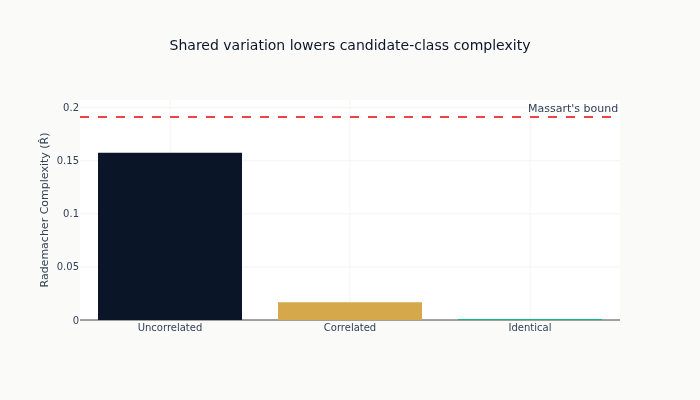

In [11]:
# Compare empirical complexities against the shared normalized bound.
fig = go.Figure()

strategies = ["Uncorrelated", "Correlated", "Identical"]
R_values = [R_uncorrelated, R_correlated, R_identical]

fig.add_trace(
    go.Bar(
        x=strategies,
        y=R_values,
        marker_color=[COLORS["blue"], COLORS["amber"], COLORS["positive"]],
        name="R̂",
    )
)

fig.add_hline(
    y=massart_bound,
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="Massart's bound",
)

fig.update_layout(
    title="Shared variation lowers candidate-class complexity",
    yaxis_title="Rademacher Complexity (R̂)",
    height=400,
)

fig.show()

With candidate count, sample size, and column norms fixed, greater shared
variation lowers the empirical complexity of this constructed class. RAS can
therefore distinguish a tightly related parameter family from the same number
of nearly independent trials.

## 2. The charge applied to a candidate class

The bound, from Paleologo's Procedure 8.2:

$$\theta_n \geq \hat{\theta}_n - 2\hat{R} - 3\sqrt{\frac{2\log(2/\delta)}{T}} - \sqrt{\frac{2\log(2N/\delta)}{T}}$$

Every term in this bound uses per-period, volatility-standardized return
units. We annualize the observed estimate and its lower bound only for display.

In [12]:
sweep_rng = np.random.default_rng(SEED)
sweep_base = sweep_rng.standard_normal(SWEEP_PERIODS) * 0.01 + 0.0002
strategy_returns = (
    sweep_base[:, None] + sweep_rng.standard_normal((SWEEP_PERIODS, SWEEP_CANDIDATES)) * 0.005
)

# Express each path in per-period Sharpe units without removing its mean.
return_volatility = np.std(strategy_returns, axis=0, ddof=1)
standardized_returns = strategy_returns / return_volatility
observed_sharpe_native = np.mean(standardized_returns, axis=0)
observed_sharpe = observed_sharpe_native * np.sqrt(252)

print(f"Candidates: {SWEEP_CANDIDATES} over {SWEEP_PERIODS} days")
print(f"  Largest observed annualized Sharpe: {np.max(observed_sharpe):.3f}")
print(f"  Mean:                               {np.mean(observed_sharpe):.3f}")
print(f"  Smallest:                           {np.min(observed_sharpe):.3f}")

Candidates: 500 over 504 days
  Largest observed annualized Sharpe: 1.281
  Mean:                               0.104
  Smallest:                           -0.950


In [13]:
R_hat = rademacher_complexity(standardized_returns, N_SIMULATIONS, SEED)
massart_returns = massart_upper_bound(standardized_returns)

print(f"Rademacher complexity of this candidate class: {R_hat:.4f}")
print(f"Massart bound for the same count and scale:    {massart_returns:.4f}")
print(f"The class realizes {R_hat / massart_returns:.0%} of the bound")

Rademacher complexity of this candidate class: 0.0631
Massart bound for the same count and scale:    0.1574
The class realizes 40% of the bound


In [14]:
# Apply the bound in native units, then annualize its result for display.
adjusted_sharpe_native = ras_sharpe_adjustment(
    observed_sharpe=observed_sharpe_native,
    complexity=R_hat,
    n_samples=SWEEP_PERIODS,
    n_strategies=SWEEP_CANDIDATES,
    delta=CONFIDENCE,
)
adjusted_sharpe = adjusted_sharpe_native * np.sqrt(252)

# Compare positive point estimates with positive RAS lower bounds.
n_positive_raw = np.sum(observed_sharpe > 0)
n_positive_ras = np.sum(adjusted_sharpe > 0)

sweep_best = int(np.argmax(observed_sharpe))
print("Candidates whose Sharpe is positive:")
print(
    f"  As a point estimate:  {n_positive_raw}/{SWEEP_CANDIDATES}"
    f" ({n_positive_raw / SWEEP_CANDIDATES:.0%})"
)
print(
    f"  As a lower bound:     {n_positive_ras}/{SWEEP_CANDIDATES}"
    f" ({n_positive_ras / SWEEP_CANDIDATES:.0%})"
)
print("Largest observed candidate:")
print(f"  Point estimate: {observed_sharpe[sweep_best]:.3f}")
print(f"  Lower bound:    {adjusted_sharpe[sweep_best]:.3f}")
print(f"  Charged:        {observed_sharpe[sweep_best] - adjusted_sharpe[sweep_best]:.3f}")

Candidates whose Sharpe is positive:
  As a point estimate:  311/500 (62%)
  As a lower bound:     0/500 (0%)
Largest observed candidate:
  Point estimate: 1.281
  Lower bound:    -9.632
  Charged:        10.913


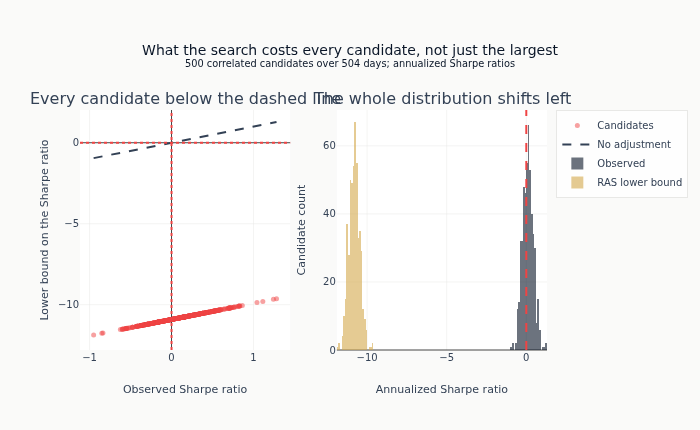

In [15]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Every candidate below the dashed line",
        "The whole distribution shifts left",
    ],
)

fig.add_trace(
    go.Scatter(
        x=observed_sharpe,
        y=adjusted_sharpe,
        mode="markers",
        marker=dict(
            size=5,
            color=np.where(adjusted_sharpe > 0, COLORS["positive"], COLORS["negative"]),
            opacity=0.5,
        ),
        name="Candidates",
    ),
    row=1,
    col=1,
)

sr_range = [float(np.min(observed_sharpe)), float(np.max(observed_sharpe))]
fig.add_trace(
    go.Scatter(
        x=sr_range,
        y=sr_range,
        mode="lines",
        line=dict(dash="dash", color=COLORS["neutral"]),
        name="No adjustment",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Histogram(
        x=observed_sharpe,
        name="Observed",
        marker_color=COLORS["blue"],
        opacity=0.6,
        nbinsx=30,
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Histogram(
        x=adjusted_sharpe,
        name="RAS lower bound",
        marker_color=COLORS["amber"],
        opacity=0.6,
        nbinsx=30,
    ),
    row=1,
    col=2,
)

fig.add_hline(y=0, line_dash="dot", line_color=COLORS["negative"], row=1, col=1)
fig.add_vline(x=0, line_dash="dot", line_color=COLORS["negative"], row=1, col=1)
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["negative"], row=1, col=2)

fig.update_layout(
    title=(
        "What the search costs every candidate, not just the largest"
        f"<br><sup>{SWEEP_CANDIDATES} correlated candidates over {SWEEP_PERIODS} days; "
        "annualized Sharpe ratios</sup>"
    ),
    height=430,
    barmode="overlay",
    margin=dict(t=110),
)
fig.update_xaxes(title_text="Observed Sharpe ratio", row=1, col=1)
fig.update_yaxes(title_text="Lower bound on the Sharpe ratio", row=1, col=1)
fig.update_xaxes(title_text="Annualized Sharpe ratio", row=1, col=2)
fig.update_yaxes(title_text="Candidate count", row=1, col=2)

fig.show()

The lower-bound distribution shifts left of the point estimates because RAS
charges for both class complexity and finite-sample uncertainty. A promising
selected Sharpe is therefore not enough: the lower bound must clear the
decision hurdle for the evidence to survive the search adjustment.

## 3. The same class through both corrections

Compare the two multiple testing corrections.

In [16]:
# Compare RAS and DSR
best_sharpe = np.max(observed_sharpe)
variance_trials = np.var(observed_sharpe, ddof=1)

# DSR analysis
dsr_result = deflated_sharpe_ratio(
    observed_sharpe=best_sharpe,
    n_trials=SWEEP_CANDIDATES,
    variance_trials=variance_trials,
    n_samples=SWEEP_PERIODS,
    return_components=True,
)

# RAS analysis (best strategy)
ras_adjusted_best = adjusted_sharpe[sweep_best]

print("=== RAS vs DSR Comparison ===")
print(f"\nBest observed Sharpe: {best_sharpe:.3f}")
print("\nDSR Analysis:")
print(f"  Expected max (E[max]): {dsr_result['expected_max_sharpe']:.3f}")
print(f"  DSR probability: {dsr_result['dsr']:.3f}")
print(f"  p-value: {dsr_result['p_value']:.4f}")

print("\nRAS Analysis:")
print(f"  Rademacher complexity: {R_hat:.4f}")
print(f"  Adjusted SR: {ras_adjusted_best:.3f}")
print(f"  Adjustment magnitude: {best_sharpe - ras_adjusted_best:.3f}")
print(f"  Positive 95% lower bound: {'Yes' if ras_adjusted_best > 0 else 'No'}")

=== RAS vs DSR Comparison ===

Best observed Sharpe: 1.281

DSR Analysis:
  Expected max (E[max]): 1.041
  DSR probability: 0.632
  p-value: 0.3677

RAS Analysis:
  Rademacher complexity: 0.0631
  Adjusted SR: -9.632
  Adjustment magnitude: 10.913
  Positive 95% lower bound: No


DSR and RAS answer different questions. DSR reports a tail probability relative
to a selection benchmark, while RAS reports a finite-sample lower bound. Reading
both prevents a probability from being mistaken for a guaranteed performance
floor.

## 4. The same charge on signal quality rather than returns

In [17]:
ic_rng = np.random.default_rng(SEED)
ic_matrix = ic_rng.uniform(-0.05, 0.05, size=(IC_PERIODS, IC_SIGNALS))
ic_matrix[:, :IC_TRUE_SIGNALS] += IC_TRUE_VALUE
observed_ic = np.mean(ic_matrix, axis=0)

print(f"Candidate signals: {IC_SIGNALS}, of which {IC_TRUE_SIGNALS} carry a real value")
print(f"Observations per signal: {IC_PERIODS}")
print(f"Largest observed mean:   {np.max(observed_ic):.4f}")
print(f"Mean across candidates:  {np.mean(observed_ic):.4f}")

Candidate signals: 50, of which 5 carry a real value
Observations per signal: 252
Largest observed mean:   0.0318
Mean across candidates:  0.0028


In [18]:
# Compute complexity in the same bounded IC units used by the adjustment.
R_hat_ic = rademacher_complexity(ic_matrix, N_SIMULATIONS, SEED)

# Apply RAS adjustment for IC
adjusted_ic = ras_ic_adjustment(
    observed_ic=observed_ic,
    complexity=R_hat_ic,
    n_samples=IC_PERIODS,
    delta=CONFIDENCE,
    kappa=IC_KAPPA,
)

ic_above_raw = int(np.sum(observed_ic > IC_HURDLE))
ic_above_ras = int(np.sum(adjusted_ic > IC_HURDLE))
real_above_raw = int(np.sum(observed_ic[:IC_TRUE_SIGNALS] > IC_HURDLE))
real_above_ras = int(np.sum(adjusted_ic[:IC_TRUE_SIGNALS] > IC_HURDLE))
noise_above_raw = int(np.sum(observed_ic[IC_TRUE_SIGNALS:] > IC_HURDLE))
noise_above_ras = int(np.sum(adjusted_ic[IC_TRUE_SIGNALS:] > IC_HURDLE))

print(f"Rademacher complexity of the signal class: {R_hat_ic:.4f}")
print(f"Signals clearing the hurdle, as a point estimate: {ic_above_raw}/{IC_SIGNALS}")
print(f"Signals clearing it as a lower bound:             {ic_above_ras}/{IC_SIGNALS}")
print(f"  Of the {IC_TRUE_SIGNALS} real signals:   {real_above_raw} raw, {real_above_ras} bounded")
print(
    f"  Of the {IC_SIGNALS - IC_TRUE_SIGNALS} null signals:  "
    f"{noise_above_raw} raw, {noise_above_ras} bounded"
)

Rademacher complexity of the signal class: 0.0043
Signals clearing the hurdle, as a point estimate: 5/50
Signals clearing it as a lower bound:             0/50
  Of the 5 real signals:   5 raw, 0 bounded
  Of the 45 null signals:  0 raw, 0 bounded


The raw hurdle identifies the deliberately shifted signals in this bounded
construction, but the RAS lower bounds remain more conservative. This is a
diagnostic of finite-sample search uncertainty, not a claim that the synthetic
signals would trade profitably.

## 5. A parameter sweep is a candidate class

A grid search over three settings does not feel like testing hundreds of strategies, and that is
precisely why it is dangerous: the count is the product of the axes, and nobody writes it down.
Seven lookbacks times five holding periods times four position counts is a hundred and forty
candidates, every one of them a trial.

The paths below are correlated synthetic draws, not a momentum strategy run on prices. Nothing
here computes a rank or rebalances anything, and no parameter value influences any return series;
the grid is used only for its size. What the section measures is how a class of this shape and
this much shared variation is charged.

In [19]:
grid_rng = np.random.default_rng(SEED)
grid_axes = {"lookback": 7, "holding": 5, "positions": 4}
grid_size = math.prod(grid_axes.values())

grid_base = grid_rng.standard_normal(SWEEP_PERIODS) * 0.01 + 0.0001
grid_returns = grid_base[:, None] + grid_rng.standard_normal((SWEEP_PERIODS, grid_size)) * 0.003
standardized_daily = grid_returns / np.std(grid_returns, axis=0, ddof=1)
daily_sharpe_native = np.mean(standardized_daily, axis=0)
sharpe_ratios = daily_sharpe_native * np.sqrt(252)

R_hat_daily = rademacher_complexity(standardized_daily, N_SIMULATIONS, SEED)
massart_daily = massart_upper_bound(standardized_daily)
adjusted_sharpe_daily = ras_sharpe_adjustment(
    observed_sharpe=daily_sharpe_native,
    complexity=R_hat_daily,
    n_samples=SWEEP_PERIODS,
    n_strategies=grid_size,
    delta=CONFIDENCE,
) * np.sqrt(252)

grid_best = int(np.argmax(sharpe_ratios))
print(f"Grid axes: {grid_axes}")
print(f"Candidates the grid actually tests: {grid_size}")
print(f"Rademacher complexity: {R_hat_daily:.4f}, Massart bound: {massart_daily:.4f}")
print(f"Largest observed annualized Sharpe: {sharpe_ratios[grid_best]:.3f}")
print(f"Its lower bound after the charge:   {adjusted_sharpe_daily[grid_best]:.3f}")
print(f"Candidates clearing a Sharpe of {GRID_HURDLE}:")
print(f"  As point estimates: {int(np.sum(sharpe_ratios > GRID_HURDLE))}")
print(f"  As lower bounds:    {int(np.sum(adjusted_sharpe_daily > GRID_HURDLE))}")

Grid axes: {'lookback': 7, 'holding': 5, 'positions': 4}
Candidates the grid actually tests: 140
Rademacher complexity: 0.0358, Massart bound: 0.1400
Largest observed annualized Sharpe: 0.520
Its lower bound after the charge:   -9.315
Candidates clearing a Sharpe of 0.5:
  As point estimates: 1
  As lower bounds:    0


The largest of a hundred and forty correlated draws is large because a hundred and forty draws
were taken, and the bound charges for exactly that. The charge here is severe enough to push the
lower bound deeply negative, which is what a finite-sample guarantee looks like when two years of
data are asked to support a hundred and forty candidates: it does not say the strategy is bad, it
says the evidence cannot rule out that it is.

The practical consequence is about bookkeeping rather than statistics. The trial count for a grid
search is the product of the axes, including the axes somebody swept once and discarded. A
correction fed the number of strategies you remember running is not a correction.

## 6. The same class at a different sampling frequency

One thing the bound is easy to get wrong is where the annualization goes. Every term in the RAS
expression is in per-period, volatility-standardized units, so the bound has to be computed at
the frequency the data arrives at and scaled afterwards. Doing it the other way - annualizing the
observed Sharpes first and then subtracting a per-period complexity - mixes units and silently
under-charges.

An hourly series makes the difference visible because its annualizer is not the square root of
252. The paths are again synthetic and correlated; no funding rate is loaded and no position is
formed.

In [20]:
hourly_rng = np.random.default_rng(SEED)
hourly_periods = 24 * HOURLY_DAYS
hourly_grid_size = 5 * 4 * 4

hourly_base = hourly_rng.standard_normal(hourly_periods) * 0.002 + 0.00005
hourly_returns = (
    hourly_base[:, None] + hourly_rng.standard_normal((hourly_periods, hourly_grid_size)) * 0.001
)
print(f"Hourly candidates: {hourly_grid_size} over {hourly_periods:,} hourly observations")

# Compute native and annualized Sharpe estimates from the standardized paths.
hourly_annualizer = np.sqrt(24 * 365)
hourly_volatility = np.std(hourly_returns, axis=0, ddof=1)
standardized_hourly = hourly_returns / hourly_volatility
hourly_sharpe_native = np.mean(standardized_hourly, axis=0)
hourly_sharpe = hourly_sharpe_native * hourly_annualizer

Hourly candidates: 80 over 2,160 hourly observations


In [21]:
# Apply RAS in per-period Sharpe units.
R_hat_hourly = rademacher_complexity(standardized_hourly, N_SIMULATIONS, SEED)
massart_hourly = massart_upper_bound(standardized_hourly)

adjusted_hourly_native = ras_sharpe_adjustment(
    observed_sharpe=hourly_sharpe_native,
    complexity=R_hat_hourly,
    n_samples=hourly_periods,
    n_strategies=hourly_grid_size,
    delta=CONFIDENCE,
)
adjusted_hourly = adjusted_hourly_native * hourly_annualizer

print(f"Annualizer at this frequency: sqrt(24 x 365) = {hourly_annualizer:.1f}")
print(f"Rademacher complexity: {R_hat_hourly:.4f}, Massart bound: {massart_hourly:.4f}")
print(f"Largest observed annualized Sharpe: {np.max(hourly_sharpe):.2f}")
print(f"Largest lower bound:                {np.max(adjusted_hourly):.2f}")
print(
    f"Candidates whose lower bound clears a Sharpe of 1: "
    f"{int(np.sum(adjusted_hourly > 1.0))}/{hourly_grid_size}"
)

Annualizer at this frequency: sqrt(24 x 365) = 93.6
Rademacher complexity: 0.0234, Massart bound: 0.0637
Largest observed annualized Sharpe: -0.00
Largest lower bound:                -28.89
Candidates whose lower bound clears a Sharpe of 1: 0/80


The hourly series carries an order of magnitude more observations than the daily one, and the
charge does not disappear. Sample size shrinks the estimation-error terms of the bound, not the
complexity term, and complexity is a property of how well the candidate set can align with noise
rather than of how much noise there is.

The annualizer here is the square root of 8,760 rather than of 252, which is why the bound was
computed before it was applied. Annualizing the observed Sharpes first and subtracting a
per-period complexity from them would have charged a strategy at this frequency roughly a sixth
of what it owes.

## References

- Paleologo, G. (2024). "Elements of Quantitative Investing", Chapter 8
- Mohri, Rostamizadeh & Talwalkar (2018). "Foundations of Machine Learning"
- GitHub: https://github.com/RSv618/rademacher-anti-serum

## Key takeaways

- Rademacher complexity measures the realized capacity of the candidate matrix,
  so dependence among trials enters directly rather than through a raw count.
- RAS must be computed from per-period volatility-standardized returns without
  demeaning; annualization is a presentation step applied afterward.
- DSR supplies a selection-adjusted probability, while RAS supplies a lower
  performance bound. They are complementary, not interchangeable.
- A strong point estimate can fail a lower-bound hurdle once class complexity
  and sampling uncertainty are included.

**Limitations.** These examples use synthetic IID paths to isolate the formulas.
Real trading returns often exhibit serial dependence and regime changes, which
require a dependence-aware resampling or concentration design. The examples
also omit transaction costs and portfolio construction.

This notebook implements the strategy-level overfitting controls discussed in
Chapter 16, §16.7. Continue to `14_cost_sensitivity` to test whether a selected
strategy remains viable when execution-cost assumptions change.

## The three calls, in order

```python
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_sharpe_adjustment,
    ras_ic_adjustment,
)

# Step 1: Standardize without demeaning, then compute native estimates
standardized = candidate_returns / candidate_returns.std(axis=0, ddof=1)
observed_native = standardized.mean(axis=0)
R_hat = rademacher_complexity(standardized, n_simulations=5000)

# Step 2: Apply RAS adjustment
adjusted_native = ras_sharpe_adjustment(
    observed_native,
    complexity=R_hat,
    n_samples=n_periods,
    n_strategies=n_candidates,
    delta=confidence,
)

# Step 3: Annualize only after applying the native-unit bound
adjusted_sharpe = adjusted_native * np.sqrt(periods_per_year)
positive_lower_bound = adjusted_sharpe > 0
```

## Which correction to reach for

| Scenario | Use |
|----------|-----|
| Independent, low-correlation trials | Compare both and state each assumption |
| Correlated parameter sweep | Use RAS or estimate effective trials before DSR |
| Quick diagnostic | Use DSR, with the raw-trial-count caveat |
| Reported research result | Report the diagnostic, inputs, and assumptions |